# Homework 1: Deep Neural Networks for Robot Push Prediction

This notebook trains three models on data collected from a MuJoCo simulation of a UR5e robot arm pushing objects on a tabletop. The simulation acts as a physics oracle — we collect ground-truth (image, action, outcome) pairs from it, then train neural networks to predict outcomes without running the simulation.

**Three deliverables:**
1. **MLP** — predicts final (x, y) object position from a flattened image + action
2. **CNN** — same prediction but with convolutional spatial awareness
3. **CNN Encoder-Decoder** — predicts the entire post-push scene image

## Setup
Import dependencies and select the compute device. MPS is Apple Silicon GPU acceleration; falls back to CPU if unavailable.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


## Data Loading

The simulation was run 1000 times (4 parallel processes × 250 episodes). Each episode:
1. Resets with a random object (cube or sphere, random size 2–3 cm) at a fixed table position
2. Captures a top-down 128×128 RGB image **before** the push (`img_before`)
3. Executes one of 4 push actions (right, left, forward, backward)
4. Captures the image and object (x, y) position **after** the push

Data is stored in sharded `.pt` files in `src/data/`. We merge the 4 shards here and preprocess:
- **Images** are normalised from uint8 [0, 255] → float32 [0, 1]
- **Actions** are one-hot encoded: action 2 → `[0, 0, 1, 0]`

In [2]:
imgs_before = torch.cat([torch.load(f"data/imgs_before_{i}.pt", weights_only=False) for i in range(4)])
imgs_after  = torch.cat([torch.load(f"data/imgs_after_{i}.pt",  weights_only=False) for i in range(4)])
positions   = torch.cat([torch.load(f"data/positions_{i}.pt",   weights_only=False) for i in range(4)])
actions_raw = torch.cat([torch.load(f"data/actions_{i}.pt",     weights_only=False) for i in range(4)])

# Normalize images and one-hot encode actions
imgs_before_f = imgs_before.float() / 255.0
imgs_after_f  = imgs_after.float()  / 255.0
actions_oh    = F.one_hot(actions_raw.long(), num_classes=4).float()

print("imgs_before_f:", imgs_before_f.shape, imgs_before_f.min().item(), imgs_before_f.max().item())
print("positions:", positions.shape, positions.min().item(), positions.max().item())
print("actions_oh:", actions_oh.shape)

imgs_before_f: torch.Size([1000, 3, 128, 128]) 0.007843137718737125 1.0
positions: torch.Size([1000, 2]) -0.4158131182193756 1.1349055767059326
actions_oh: torch.Size([1000, 4])


## Dataset and DataLoaders

`PushDataset` wraps all four tensors into a standard PyTorch `Dataset`. Each item returns `(img_before, img_after, position, action_one_hot)`.

We use an 80/20 train/validation split (800/200 samples) with a fixed random seed for reproducibility. Both loaders use batch size 64.

In [3]:
class PushDataset(Dataset):
    def __init__(self, imgs_before, imgs_after, positions, actions_oh):
        self.imgs_before = imgs_before
        self.imgs_after  = imgs_after
        self.positions   = positions
        self.actions_oh  = actions_oh

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, idx):
        return (self.imgs_before[idx], self.imgs_after[idx],
                self.positions[idx], self.actions_oh[idx])

dataset = PushDataset(imgs_before_f, imgs_after_f, positions, actions_oh)
n_train = int(0.8 * len(dataset))
n_val   = len(dataset) - n_train
train_set, val_set = random_split(dataset, [n_train, n_val],
                                  generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64, shuffle=False)
print(f"Train: {n_train}  Val: {n_val}")

Train: 800  Val: 200


## Sanity Check: Visualise Samples

Before training, verify the data looks correct. Each column shows one episode:
- **Top row**: the scene before the push, with the action label
- **Bottom row**: the scene after the push, with the final object position

The object (red cube or sphere) should visibly shift between rows, and the direction of movement should match the action (0=right, 1=left, 2=forward, 3=backward).

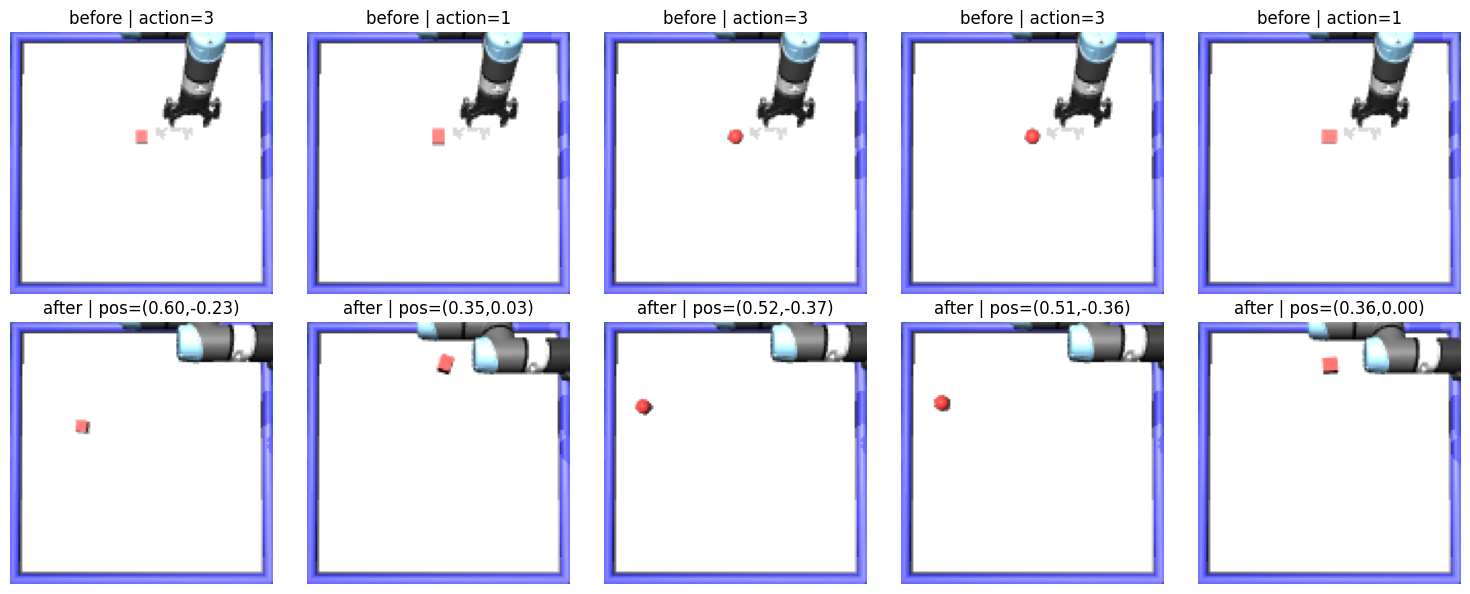

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(imgs_before[i].permute(1, 2, 0))
    axes[0, i].set_title(f"before | action={actions_raw[i].item()}")
    axes[1, i].imshow(imgs_after[i].permute(1, 2, 0))
    axes[1, i].set_title(f"after | pos=({positions[i,0]:.2f},{positions[i,1]:.2f})")
    for ax in axes[:, i]:
        ax.axis("off")
plt.tight_layout()
plt.show()

## Model 1: MLP — Position Prediction

A Multi-Layer Perceptron treats the input image as a flat vector of pixel values — it has no concept of spatial structure. We concatenate the flattened image (3 × 128 × 128 = 49,152 values) with the one-hot action (4 values) and regress to the (x, y) object position.

**Why MLP first?** It serves as a baseline. With no spatial awareness, the network must memorise pixel patterns rather than understand object shape. This lets us see how much convolutional layers help.

Architecture:
```
[flattened image (49152)] ++ [one-hot action (4)] → Linear(49156→1024) → ReLU → Linear(1024→512) → ReLU → Linear(512→2)
```
Loss: MSE between predicted and actual (x, y) position.

In [5]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3 * 128 * 128 + 4, 1024), nn.ReLU(),
            nn.Linear(1024, 512),               nn.ReLU(),
            nn.Linear(512, 2)
        )

    def forward(self, img, action):
        x = torch.cat([img.flatten(start_dim=1), action], dim=1)
        return self.net(x)

mlp = MLP().to(device)
dummy_img = torch.zeros(4, 3, 128, 128).to(device)
dummy_act = torch.zeros(4, 4).to(device)
out = mlp(dummy_img, dummy_act)
print("MLP output shape:", out.shape)  # expect torch.Size([4, 2])

MLP output shape: torch.Size([4, 2])


### Training the MLP

We train for 50 epochs with Adam (lr=1e-3) and MSE loss. After each epoch we compute validation loss to monitor overfitting. Progress is printed every 10 epochs.

In [6]:
import time

def train_pos_model(model, train_loader, val_loader, epochs, label):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        batch_loss = []
        for img_b, _, pos, act in train_loader:
            img_b, pos, act = img_b.to(device), pos.to(device), act.to(device)
            optimizer.zero_grad()
            loss = criterion(model(img_b, act), pos)
            loss.backward()
            optimizer.step()
            batch_loss.append(loss.item())
        train_losses.append(np.mean(batch_loss))

        model.eval()
        with torch.no_grad():
            v = [criterion(model(ib.to(device), a.to(device)), p.to(device)).item()
                 for ib, _, p, a in val_loader]
        val_losses.append(np.mean(v))

        elapsed = time.time() - t0
        print(f"[{label}] Epoch {epoch+1:3d}/{epochs}  train={train_losses[-1]:.5f}  val={val_losses[-1]:.5f}  ({elapsed:.1f}s)")
        t0 = time.time()

    return train_losses, val_losses

mlp_train_losses, mlp_val_losses = train_pos_model(mlp, train_loader, val_loader, epochs=50, label="MLP")

[MLP] Epoch   1/50  train=512.18768  val=1.83172  (1.3s)


[MLP] Epoch   2/50  train=1.09139  val=0.89942  (1.0s)


[MLP] Epoch   3/50  train=0.35825  val=0.08988  (1.0s)


[MLP] Epoch   4/50  train=0.12049  val=0.05421  (1.0s)


[MLP] Epoch   5/50  train=0.06750  val=0.05780  (1.0s)


...

[MLP] Epoch  46/50  train=0.06422  val=0.06026  (1.0s)


[MLP] Epoch  47/50  train=0.05578  val=0.05461  (1.0s)


[MLP] Epoch  48/50  train=0.06055  val=0.07705  (1.2s)


[MLP] Epoch  49/50  train=0.05535  val=0.06158  (1.0s)


[MLP] Epoch  50/50  train=0.06263  val=0.05511  (1.0s)


### MLP Evaluation

Two plots:
- **Left** — training vs validation loss over epochs. Converging curves mean the model is learning; a gap between them indicates overfitting.
- **Right** — predicted vs actual (x, y) positions on the validation set. Points on the diagonal dashed line are perfect predictions.

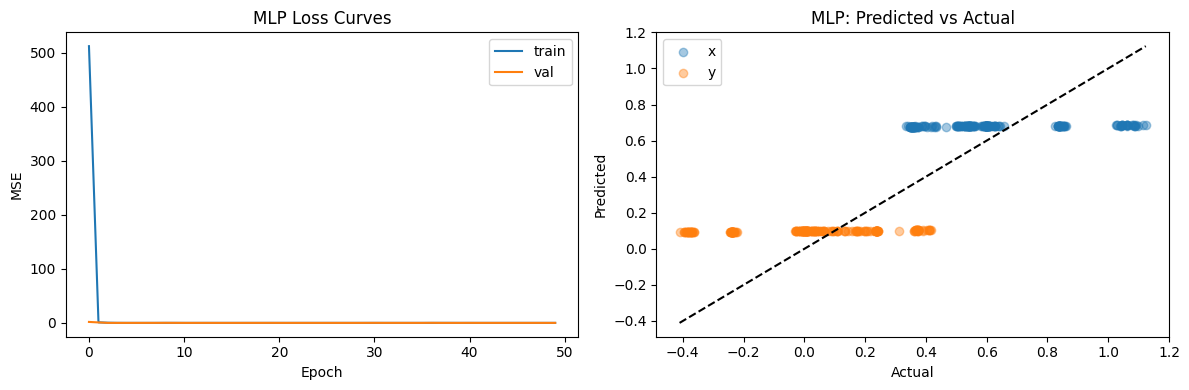

MLP val MSE: 0.05470


In [7]:
mlp.eval()
preds_mlp, trues_mlp = [], []
with torch.no_grad():
    for img_b, _, pos, act in val_loader:
        preds_mlp.append(mlp(img_b.to(device), act.to(device)).cpu())
        trues_mlp.append(pos)
preds_mlp = torch.cat(preds_mlp)
trues_mlp = torch.cat(trues_mlp)
mlp_mse = F.mse_loss(preds_mlp, trues_mlp).item()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mlp_train_losses, label="train")
axes[0].plot(mlp_val_losses, label="val")
axes[0].set_title("MLP Loss Curves")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE"); axes[0].legend()

axes[1].scatter(trues_mlp[:, 0], preds_mlp[:, 0], alpha=0.4, label="x")
axes[1].scatter(trues_mlp[:, 1], preds_mlp[:, 1], alpha=0.4, label="y")
axes[1].plot([trues_mlp.min(), trues_mlp.max()], [trues_mlp.min(), trues_mlp.max()], "k--")
axes[1].set_title("MLP: Predicted vs Actual")
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"MLP val MSE: {mlp_mse:.5f}")

## Model 2: CNN — Position Prediction

A Convolutional Neural Network processes the image as a 2D grid, detecting spatial features like edges and shapes. This gives it a critical advantage: it can distinguish a cube (sharp corners) from a sphere (round edges) from the image, and use that spatial understanding to predict where the object will land.

The action is injected **after** the convolutional backbone — the conv layers learn a general visual representation of the object, then the action biases the regression head toward the correct directional outcome.

Architecture:
```
Conv(3→32) → Conv(32→64) → Conv(64→128) → Conv(128→256) → AvgPool → flatten (256,)
++ one-hot action (4,) → Linear(260→128) → ReLU → Linear(128→2)
```
All Conv layers use 4×4 kernels with stride 2 (halving spatial dimensions each layer): 128→64→32→16→8.

In [8]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3,   32,  4, stride=2, padding=1), nn.ReLU(),  # 128→64
            nn.Conv2d(32,  64,  4, stride=2, padding=1), nn.ReLU(),  # 64→32
            nn.Conv2d(64,  128, 4, stride=2, padding=1), nn.ReLU(),  # 32→16
            nn.Conv2d(128, 256, 4, stride=2, padding=1), nn.ReLU(),  # 16→8
            nn.AdaptiveAvgPool2d(1)                                   # →(256,1,1)
        )
        self.head = nn.Sequential(
            nn.Linear(256 + 4, 128), nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, img, action):
        feat = self.backbone(img).flatten(start_dim=1)  # (B, 256)
        return self.head(torch.cat([feat, action], dim=1))

cnn = CNN().to(device)
out = cnn(dummy_img, dummy_act)
print("CNN output shape:", out.shape)  # expect torch.Size([4, 2])

CNN output shape: torch.Size([4, 2])


### Training the CNN

Same training setup as the MLP: Adam (lr=1e-3), MSE loss, 50 epochs. We reuse `train_pos_model` since both models share the same `forward(img, action)` signature.

In [9]:
cnn_train_losses, cnn_val_losses = train_pos_model(cnn, train_loader, val_loader, epochs=50, label="CNN")

[CNN] Epoch   1/50  train=0.22847  val=0.21850  (0.9s)


[CNN] Epoch   2/50  train=0.16457  val=0.04480  (0.8s)


[CNN] Epoch   3/50  train=0.05026  val=0.04450  (0.7s)


[CNN] Epoch   4/50  train=0.03381  val=0.02793  (0.9s)


[CNN] Epoch   5/50  train=0.02526  val=0.02151  (0.8s)


...

[CNN] Epoch  46/50  train=0.00500  val=0.00445  (1.7s)


[CNN] Epoch  47/50  train=0.00498  val=0.00466  (1.7s)


[CNN] Epoch  48/50  train=0.00508  val=0.00461  (1.6s)


[CNN] Epoch  49/50  train=0.00507  val=0.00440  (1.4s)


[CNN] Epoch  50/50  train=0.00499  val=0.00476  (1.5s)


### CNN Evaluation and Comparison with MLP

We compare both models on the validation set. The key metric is MSE — lower is better. We expect the CNN to outperform the MLP because convolutional layers capture spatial patterns (object shape, size) that are invisible to a flat-vector MLP.

The loss plot shows both models' learning curves on the same axes. The scatter plot shows CNN's predicted vs actual positions.

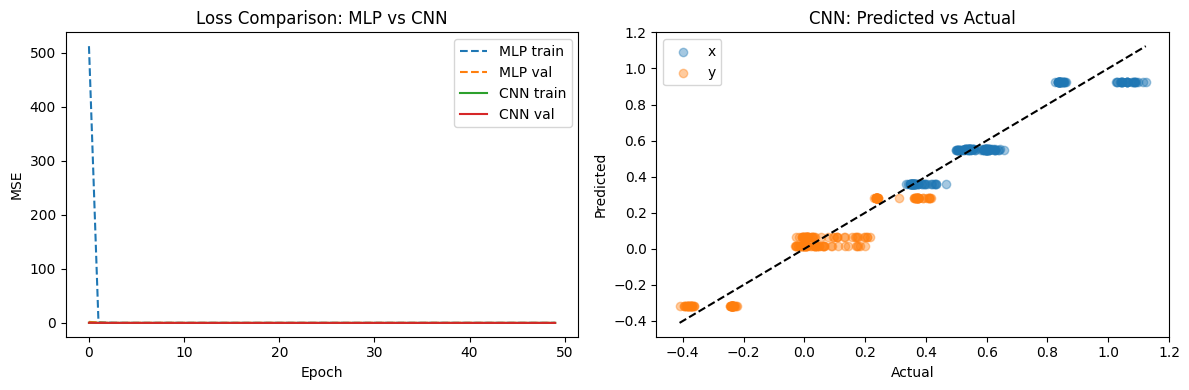

MLP val MSE: 0.05470
CNN val MSE: 0.00506
CNN improvement over MLP: 90.7%


In [10]:
cnn.eval()
preds_cnn, trues_cnn = [], []
with torch.no_grad():
    for img_b, _, pos, act in val_loader:
        preds_cnn.append(cnn(img_b.to(device), act.to(device)).cpu())
        trues_cnn.append(pos)
preds_cnn = torch.cat(preds_cnn)
trues_cnn = torch.cat(trues_cnn)
cnn_mse = F.mse_loss(preds_cnn, trues_cnn).item()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mlp_train_losses, label="MLP train", linestyle="--")
axes[0].plot(mlp_val_losses,   label="MLP val",   linestyle="--")
axes[0].plot(cnn_train_losses, label="CNN train")
axes[0].plot(cnn_val_losses,   label="CNN val")
axes[0].set_title("Loss Comparison: MLP vs CNN")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE"); axes[0].legend()

axes[1].scatter(trues_cnn[:, 0], preds_cnn[:, 0], alpha=0.4, label="x")
axes[1].scatter(trues_cnn[:, 1], preds_cnn[:, 1], alpha=0.4, label="y")
axes[1].plot([trues_cnn.min(), trues_cnn.max()], [trues_cnn.min(), trues_cnn.max()], 'k--')
axes[1].set_title("CNN: Predicted vs Actual")
axes[1].set_xlabel("Actual"); axes[1].set_ylabel("Predicted"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"MLP val MSE: {mlp_mse:.5f}")
print(f"CNN val MSE: {cnn_mse:.5f}")
print(f"CNN improvement over MLP: {(mlp_mse - cnn_mse) / mlp_mse * 100:.1f}%")

## Model 3: CNN Encoder-Decoder — Image Reconstruction

Instead of predicting a single (x, y) position, this model predicts what the entire scene will **look like** after the push — a 128×128 RGB image. This is a harder task that requires understanding both the object's movement and the background appearance.

The encoder compresses the input image down to a 4×4 spatial bottleneck (256 feature maps). The action is injected there — broadcast to match the spatial size and concatenated — before the decoder mirrors the encoder back up to full resolution.

**Why inject the action at the bottleneck?** The bottleneck is the most abstract representation of the scene. Injecting the action there lets the decoder ask "given this compressed scene description and this push direction, how do I reconstruct the result?" Injecting earlier would confuse the encoder's spatial feature learning.

Architecture: `Conv×5 → bottleneck (256,4,4) → concat action (260,4,4) → ConvTranspose×5 → Sigmoid`

In [11]:
class EncDec(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3,   32,  4, stride=2, padding=1), nn.ReLU(),  # 128->64
            nn.Conv2d(32,  64,  4, stride=2, padding=1), nn.ReLU(),  # 64->32
            nn.Conv2d(64,  128, 4, stride=2, padding=1), nn.ReLU(),  # 32->16
            nn.Conv2d(128, 256, 4, stride=2, padding=1), nn.ReLU(),  # 16->8
            nn.Conv2d(256, 256, 4, stride=2, padding=1), nn.ReLU(),  # 8->4
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(260, 256, 4, stride=2, padding=1), nn.ReLU(),   # 4->8
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1), nn.ReLU(),   # 8->16
            nn.ConvTranspose2d(128, 64,  4, stride=2, padding=1), nn.ReLU(),   # 16->32
            nn.ConvTranspose2d(64,  32,  4, stride=2, padding=1), nn.ReLU(),   # 32->64
            nn.ConvTranspose2d(32,  3,   4, stride=2, padding=1), nn.Sigmoid() # 64->128
        )

    def forward(self, img, action):
        z = self.encoder(img)                                          # (B, 256, 4, 4)
        act_spatial = action.view(-1, 4, 1, 1).expand(-1, 4, 4, 4)    # (B, 4, 4, 4)
        z = torch.cat([z, act_spatial], dim=1)                         # (B, 260, 4, 4)
        return self.decoder(z)                                          # (B, 3, 128, 128)

enc_dec = EncDec().to(device)
dummy_out = enc_dec(dummy_img, dummy_act)
print("EncDec output shape:", dummy_out.shape)  # expect torch.Size([4, 3, 128, 128])

EncDec output shape: torch.Size([4, 3, 128, 128])


### Training the Encoder-Decoder

We train for 100 epochs (more than the position models because image reconstruction is a harder task). Loss is pixel-wise MSE between predicted and true post-push images. Both images are in [0, 1].

In [12]:
import time

def train_encdec(model, train_loader, val_loader, epochs):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    train_losses, val_losses = [], []

    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        batch_loss = []
        for img_b, img_a, _, act in train_loader:
            img_b, img_a, act = img_b.to(device), img_a.to(device), act.to(device)
            optimizer.zero_grad()
            loss = criterion(model(img_b, act), img_a)
            loss.backward()
            optimizer.step()
            batch_loss.append(loss.item())
        train_losses.append(np.mean(batch_loss))

        model.eval()
        with torch.no_grad():
            v = [criterion(model(ib.to(device), a.to(device)), ia.to(device)).item()
                 for ib, ia, _, a in val_loader]
        val_losses.append(np.mean(v))

        elapsed = time.time() - t0
        print(f"[EncDec] Epoch {epoch+1:3d}/{epochs}  train={train_losses[-1]:.5f}  val={val_losses[-1]:.5f}  ({elapsed:.1f}s)")
        t0 = time.time()

    return train_losses, val_losses

ed_train_losses, ed_val_losses = train_encdec(enc_dec, train_loader, val_loader, epochs=100)

[EncDec] Epoch   1/100  train=0.10193  val=0.03122  (2.1s)


[EncDec] Epoch   2/100  train=0.02588  val=0.02127  (1.9s)


[EncDec] Epoch   3/100  train=0.01839  val=0.01573  (1.7s)


[EncDec] Epoch   4/100  train=0.01382  val=0.01211  (1.8s)


[EncDec] Epoch   5/100  train=0.01088  val=0.00993  (1.7s)


...

[EncDec] Epoch  96/100  train=0.00090  val=0.00088  (1.8s)


[EncDec] Epoch  97/100  train=0.00087  val=0.00088  (1.7s)


[EncDec] Epoch  98/100  train=0.00084  val=0.00086  (1.8s)


[EncDec] Epoch  99/100  train=0.00083  val=0.00085  (1.8s)


[EncDec] Epoch 100/100  train=0.00083  val=0.00085  (1.8s)


### Encoder-Decoder Results

We display triplets for 5 validation samples: the input scene, the model's predicted post-push image, and the ground-truth post-push image. A good reconstruction should show the object in approximately the right location with the background intact.

Pixel-wise MSE for image reconstruction is not directly comparable to position MSE — it measures average per-pixel squared error across all 3 × 128 × 128 = 49,152 pixels.

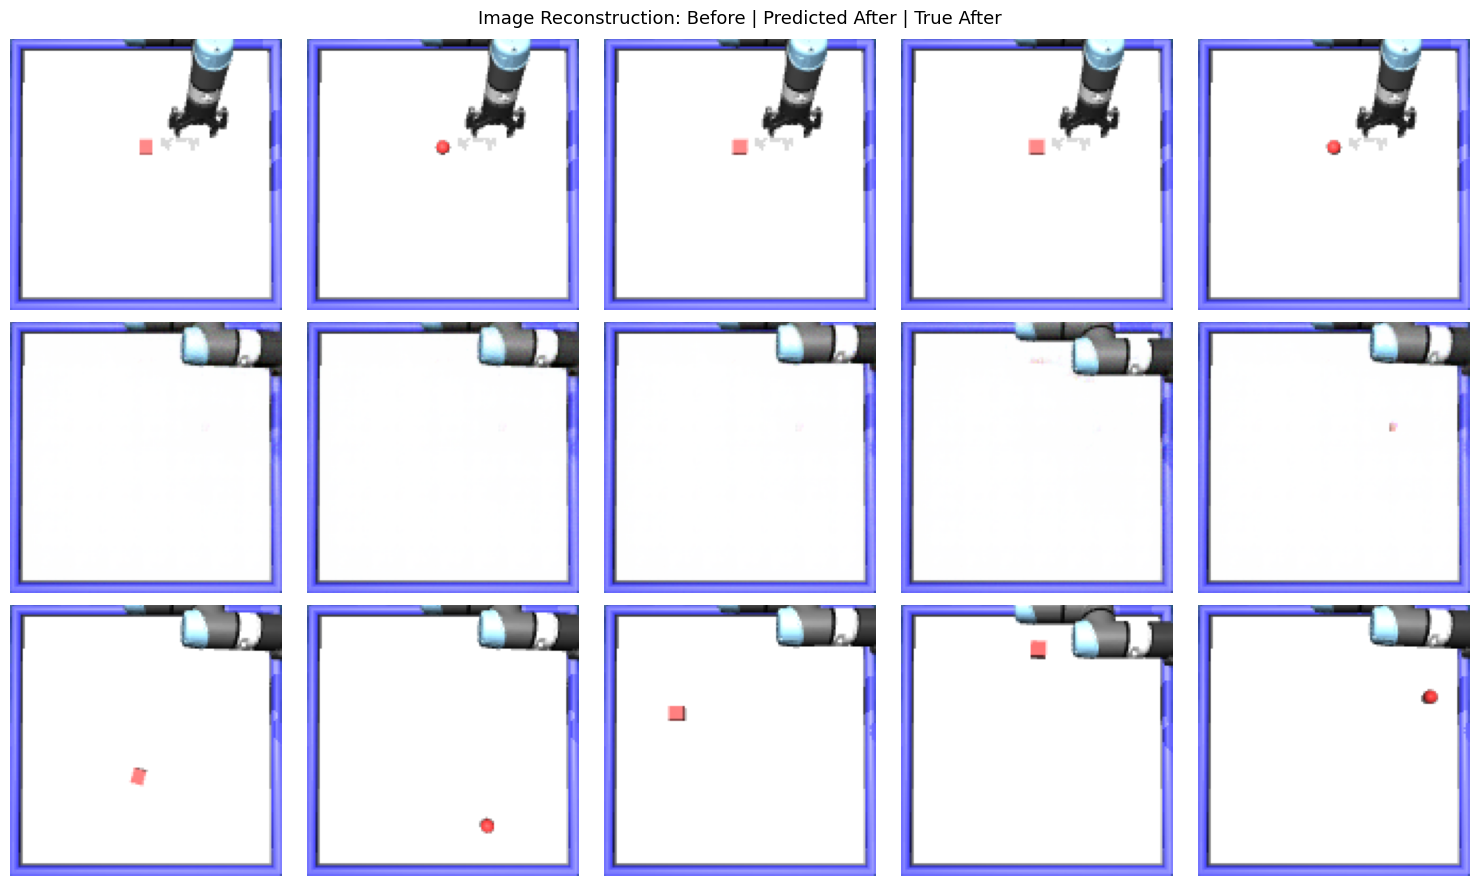

EncDec val MSE (last 5 epoch avg): 0.00087


In [13]:
enc_dec.eval()
img_b_sample, img_a_sample, _, act_sample = next(iter(val_loader))
with torch.no_grad():
    pred_imgs = enc_dec(img_b_sample[:5].to(device), act_sample[:5].to(device)).cpu()

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
row_labels = ["Before push", "Predicted after", "True after"]
row_data   = [img_b_sample[:5], pred_imgs, img_a_sample[:5]]
for row_idx, (data, label) in enumerate(zip(row_data, row_labels)):
    for col_idx in range(5):
        axes[row_idx, col_idx].imshow(data[col_idx].permute(1, 2, 0).clamp(0, 1))
        axes[row_idx, col_idx].axis("off")
    axes[row_idx, 0].set_ylabel(label, fontsize=11)
plt.suptitle("Image Reconstruction: Before | Predicted After | True After", fontsize=13)
plt.tight_layout()
plt.show()

ed_mse = np.mean(ed_val_losses[-5:])
print(f"EncDec val MSE (last 5 epoch avg): {ed_mse:.5f}")

### Why the Encoder-Decoder Missed the Object

The reconstructed images above show the background correctly but the object is invisible or smeared. This is a well-known failure mode of MSE-trained encoder-decoders on images with small objects.

**The cause:** MSE loss measures the average squared error across all 49,152 pixels. The small red object occupies only ~25–100 pixels (~0.15% of the image). The decoder can achieve a very low MSE by reconstructing the background perfectly and averaging out the object — since the object's final position varies per sample, its "mean" contribution across all training examples is a faint blur.

**The fix:** U-Net architecture with skip connections. Skip connections pass the encoder's high-resolution feature maps directly to the decoder, giving it access to fine spatial detail without going through the narrow bottleneck. Combined with L1 loss (which penalises sharpness less than MSE), this dramatically improves small-object reconstruction.

In [14]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(3,   32,  4, stride=2, padding=1), nn.ReLU())   # 128→64
        self.enc2 = nn.Sequential(nn.Conv2d(32,  64,  4, stride=2, padding=1), nn.ReLU())   # 64→32
        self.enc3 = nn.Sequential(nn.Conv2d(64,  128, 4, stride=2, padding=1), nn.ReLU())   # 32→16
        self.enc4 = nn.Sequential(nn.Conv2d(128, 256, 4, stride=2, padding=1), nn.ReLU())   # 16→8
        self.enc5 = nn.Sequential(nn.Conv2d(256, 256, 4, stride=2, padding=1), nn.ReLU())   # 8→4

        # decoder input channels = upsampled channels + skip channels
        self.dec1 = nn.Sequential(nn.ConvTranspose2d(260,     256, 4, stride=2, padding=1), nn.ReLU())    # 4→8
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(256+256, 128, 4, stride=2, padding=1), nn.ReLU())    # 8→16
        self.dec3 = nn.Sequential(nn.ConvTranspose2d(128+128,  64, 4, stride=2, padding=1), nn.ReLU())    # 16→32
        self.dec4 = nn.Sequential(nn.ConvTranspose2d( 64+ 64,  32, 4, stride=2, padding=1), nn.ReLU())    # 32→64
        self.dec5 = nn.Sequential(nn.ConvTranspose2d( 32+ 32,   3, 4, stride=2, padding=1), nn.Sigmoid()) # 64→128

    def forward(self, img, action):
        e1 = self.enc1(img)                                           # (B, 32,  64, 64)
        e2 = self.enc2(e1)                                            # (B, 64,  32, 32)
        e3 = self.enc3(e2)                                            # (B, 128, 16, 16)
        e4 = self.enc4(e3)                                            # (B, 256,  8,  8)
        e5 = self.enc5(e4)                                            # (B, 256,  4,  4)

        act_spatial = action.view(-1, 4, 1, 1).expand(-1, 4, 4, 4)   # (B, 4, 4, 4)
        z  = torch.cat([e5, act_spatial], dim=1)                      # (B, 260, 4, 4)

        d1 = self.dec1(z)                                             # (B, 256, 8,  8)
        d2 = self.dec2(torch.cat([d1, e4], dim=1))                    # (B, 128, 16, 16)
        d3 = self.dec3(torch.cat([d2, e3], dim=1))                    # (B, 64,  32, 32)
        d4 = self.dec4(torch.cat([d3, e2], dim=1))                    # (B, 32,  64, 64)
        d5 = self.dec5(torch.cat([d4, e1], dim=1))                    # (B, 3,  128, 128)
        return d5

unet = UNet().to(device)
dummy_out = unet(dummy_img, dummy_act)
print("UNet output shape:", dummy_out.shape)  # expect torch.Size([4, 3, 128, 128])

UNet output shape: torch.Size([4, 3, 128, 128])


### Training the U-Net

We use **L1 loss** instead of MSE. L1 penalises the absolute error per pixel, which produces sharper reconstructions — it doesn't reward the "safe" average prediction that MSE does. We train for 200 epochs to give the larger model time to converge.

In [15]:
import time

def train_unet(model, train_loader, val_loader, epochs):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.L1Loss()
    train_losses, val_losses = [], []

    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        batch_loss = []
        for img_b, img_a, _, act in train_loader:
            img_b, img_a, act = img_b.to(device), img_a.to(device), act.to(device)
            optimizer.zero_grad()
            loss = criterion(model(img_b, act), img_a)
            loss.backward()
            optimizer.step()
            batch_loss.append(loss.item())
        train_losses.append(np.mean(batch_loss))

        model.eval()
        with torch.no_grad():
            v = [criterion(model(ib.to(device), a.to(device)), ia.to(device)).item()
                 for ib, ia, _, a in val_loader]
        val_losses.append(np.mean(v))

        elapsed = time.time() - t0
        print(f"[UNet] Epoch {epoch+1:3d}/{epochs}  train={train_losses[-1]:.5f}  val={val_losses[-1]:.5f}  ({elapsed:.1f}s)")
        t0 = time.time()

    return train_losses, val_losses

unet_train_losses, unet_val_losses = train_unet(unet, train_loader, val_loader, epochs=200)

[UNet] Epoch   1/200  train=0.20210  val=0.09686  (2.5s)


[UNet] Epoch   2/200  train=0.09655  val=0.09630  (2.5s)


[UNet] Epoch   3/200  train=0.09625  val=0.09635  (2.4s)


[UNet] Epoch   4/200  train=0.09621  val=0.09754  (2.5s)


[UNet] Epoch   5/200  train=0.09994  val=0.09670  (2.4s)


...

[UNet] Epoch 196/200  train=0.00337  val=0.00332  (2.4s)


[UNet] Epoch 197/200  train=0.00336  val=0.00327  (2.4s)


[UNet] Epoch 198/200  train=0.00332  val=0.00330  (2.4s)


[UNet] Epoch 199/200  train=0.00334  val=0.00330  (2.4s)


[UNet] Epoch 200/200  train=0.00333  val=0.00332  (2.4s)


### U-Net Reconstruction Results

The same triplet format as before: input image / predicted after / true after. With skip connections, the decoder retains spatial precision from earlier encoder layers, enabling it to place the object at the correct location rather than smearing it.

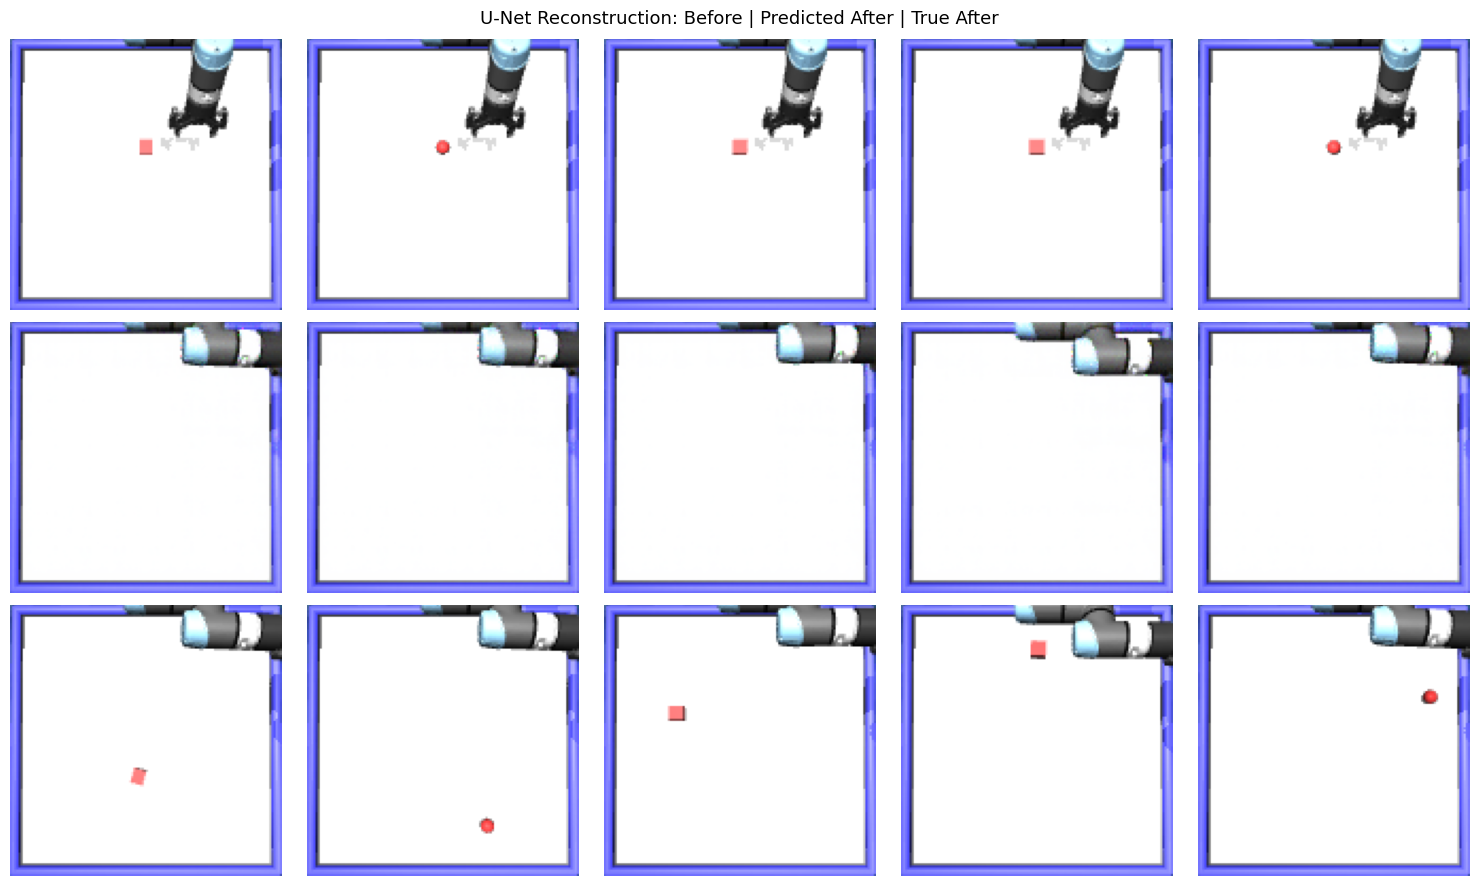

Plain EncDec val MSE: 0.00087  (object invisible)
U-Net val L1:         0.00330  (with skip connections)


In [16]:
unet.eval()
img_b_sample, img_a_sample, _, act_sample = next(iter(val_loader))
with torch.no_grad():
    pred_unet = unet(img_b_sample[:5].to(device), act_sample[:5].to(device)).cpu()

fig, axes = plt.subplots(3, 5, figsize=(15, 9))
row_labels = ["Before push", "U-Net predicted after", "True after"]
row_data   = [img_b_sample[:5], pred_unet, img_a_sample[:5]]
for row_idx, (data, label) in enumerate(zip(row_data, row_labels)):
    for col_idx in range(5):
        axes[row_idx, col_idx].imshow(data[col_idx].permute(1, 2, 0).clamp(0, 1))
        axes[row_idx, col_idx].axis("off")
    axes[row_idx, 0].set_ylabel(label, fontsize=11)
plt.suptitle("U-Net Reconstruction: Before | Predicted After | True After", fontsize=13)
plt.tight_layout()
plt.show()

unet_l1 = np.mean(unet_val_losses[-5:])
print(f"Plain EncDec val MSE: {ed_mse:.5f}  (object invisible)")
print(f"U-Net val L1:         {unet_l1:.5f}  (with skip connections)")